# Squat LLM Results Inspector

Notebook do analizy wyników LLM dla nagrań squat. Wczytuje wyniki z `results`, pobiera wideo, nakłada błędy na klatki, pokazuje surowy output LLM i porównuje predykcje z ground truth z datasetu MLPSD.

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

BASE_DIR = Path('/Users/kubak/Desktop/MasterDegree')
PROJECT_ROOT = BASE_DIR / 'github' / 'LanguageModule'
sys.path.insert(0, str(PROJECT_ROOT))

from video_llm_evaluation.constants import ERROR_CLASSES
from video_llm_evaluation.notebook_support import (
    MetricsNotAvailable,
    build_summary_dataframe,
    discover_runs,
    filter_results_by_split,
    gt_summary_for_video,
    intervals_from_payload,
    load_metrics_report,
    load_mlpsd_dataframe,
    load_results_dataframe,
    predicted_errors_from_payload,
    resolve_video_path,
    select_run,
    select_video,
    show_class_card,
    show_report,
    write_review_page,
)

DATASET_PATH = BASE_DIR / 'dataset' / 'datasets' / 'MLPSD' / 'final_dataset' / 'latest' / 'MLPSD_v2.0_feature_extracted_v3.0.0_all_with_holistic_phases.pkl'
PREPROCESSED_VIDEOS_ROOT = BASE_DIR / 'videos' / 'Nagrania' / 'Squat' / 'preprocessed'
RUNS_ROOT = PROJECT_ROOT / 'results' / 'llm_evaluation'

# ---- Z ktorego runu bierzemy WSZYSTKO: nagrania, predykcje, review app, metryki ----
SELECTED_MODEL = 'gemini-3.8-flash'
SELECTED_FPS = 2.0

# Wersja promptu jest warunkiem runu tak samo jak model i fps: 'v1' i 'v2' zadaly
# modelowi rozne pytania, wiec ich wyniki to nie jeden wynik. Bez tego pola wybor
# runu jest niejednoznaczny, gdy ten sam model przy tym samym fps ma runy dla obu
# promptow. Wartosc pochodzi z kolumny prompt_version w tabeli runow ponizej.
SELECTED_PROMPT_VERSION = 'v2'

# Ktory split MLPSD ogladamy. 'test' to domyslna wartosc calego pipeline'u.
# Metryki czytane sa z metrics/split_<SELECTED_SPLIT>/, a lista nagran ponizej
# jest do niego ograniczona. 'all' wylacza filtrowanie.
SELECTED_SPLIT = 'test'

SELECTED_VIDEO_ID = None
SELECTED_INDEX = 0
MAX_FRAMES_TO_RENDER = 400
FRAME_STEP = 1


## Wybór runu

Wszystko poniżej — lista nagrań, podgląd klatek, review app i metryki — pochodzi
z runu wybranego przez `SELECTED_MODEL` i `SELECTED_FPS` z komórki konfiguracyjnej.

`video_fps_source = inferred` oznacza run sprzed flagi `--video-fps`: pokazane 1.0
to domyślna wartość API, a nie liczba zapisana przez pipeline.

In [2]:
runs_df = discover_runs(RUNS_ROOT, dataset_path=DATASET_PATH)
display(runs_df.drop(columns=['results_root']))

RESULTS_ROOT = select_run(
    runs_df,
    model=SELECTED_MODEL,
    video_fps=SELECTED_FPS,
    prompt_version=SELECTED_PROMPT_VERSION,
)
print(f'RESULTS_ROOT = {RESULTS_ROOT}')
print(f'SELECTED_SPLIT = {SELECTED_SPLIT}')
print(f'SELECTED_PROMPT_VERSION = {SELECTED_PROMPT_VERSION}')


,run,model,video_fps,video_fps_source,media_processing,thinking_level,prompt_version,predictions,split_requested,content,metrics_for
0,squat,gemini-3.1-pro-preview,1.0,inferred,—,—,—,20,—,train:6 val:4 test:4 unmatched:6,"all, test"
1,squat__gemini-3.1-pro-preview__fps2,gemini-3.1-pro-preview,2.0,recorded,STATIC,MEDIUM,v1,5,—,train:1 val:3 unmatched:1,all
2,squat__gemini-3.8-flash__fps2,gemini-3.8-flash,2.0,recorded,STATIC,MEDIUM,v1,64,test,train:8 val:4 test:42 unmatched:10,"all, test"
3,squat__gemini-3.8-flash__fps2__v2,gemini-3.8-flash,2.0,recorded,STATIC,MEDIUM,v2,42,test,test:42,test


RESULTS_ROOT = /Users/kubak/Desktop/MasterDegree/github/LanguageModule/results/llm_evaluation/squat__gemini-3.8-flash__fps2__v2
SELECTED_SPLIT = test
SELECTED_PROMPT_VERSION = v2


## Wczytanie wyników `results`

Ta sekcja ładuje pliki wygenerowane przez CLI: `manifest.csv`, `predictions_json` i, jeśli są dostępne, `raw_responses` oraz `labels_npy`.

In [3]:
results_df = load_results_dataframe(RESULTS_ROOT, videos_root=PREPROCESSED_VIDEOS_ROOT)
results_df = filter_results_by_split(
    results_df, RESULTS_ROOT, split=SELECTED_SPLIT, dataset_path=DATASET_PATH
)
print(f'{len(results_df)} nagran w splicie {SELECTED_SPLIT!r}')
display(results_df.head(10))


42 nagran w splicie 'test'


,video_id,prediction_path,relative_dir,video_path_from_results,duration_s,model_name,prompt_version,predictions,global_confidence,notes,video_path,duration_s_manifest,fps,num_frames,ground_truth_path,dataset_split
0,1-0001-149-1-1-3-0-0,/Users/kubak/Desktop/MasterDegree/github/Langu...,formcheck/1-0001-149-1-1-3-0-0,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,6.00,gemini-3.8-flash,v2,"[{'error_type': 'Squat-depth', 'present': Fals...",None,None,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,6.000000,30.0,180,NaN,test
1,1-0006-160-1-1-3-0-0,/Users/kubak/Desktop/MasterDegree/github/Langu...,formcheck/1-0006-160-1-1-3-0-0,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,8.00,gemini-3.8-flash,v2,"[{'error_type': 'Squat-depth', 'present': True...",None,None,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,8.000000,30.0,240,NaN,test
2,1-0008-1-2-1-3-0-0,/Users/kubak/Desktop/MasterDegree/github/Langu...,formcheck/1-0008-1-2-1-3-0-0,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,10.97,gemini-3.8-flash,v2,"[{'error_type': 'Squat-depth', 'present': Fals...",None,None,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,10.966667,30.0,329,NaN,test
3,1-0016-60-8-1-0-0-0,/Users/kubak/Desktop/MasterDegree/github/Langu...,formcheck/1-0016-60-8-1-0-0-0,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,106.97,gemini-3.8-flash,v2,"[{'error_type': 'Squat-depth', 'present': Fals...",None,None,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,106.966667,30.0,3209,NaN,test
4,1-0027-60-2-1-1-0-0,/Users/kubak/Desktop/MasterDegree/github/Langu...,formcheck/1-0027-60-2-1-1-0-0,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,10.00,gemini-3.8-flash,v2,"[{'error_type': 'Squat-depth', 'present': Fals...",None,None,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,10.000000,30.0,300,NaN,test
5,1-0032-1-4-1-2-0-1,/Users/kubak/Desktop/MasterDegree/github/Langu...,formcheck/1-0032-1-4-1-2-0-1,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,15.00,gemini-3.8-flash,v2,"[{'error_type': 'Squat-depth', 'present': Fals...",None,None,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,15.000000,30.0,450,NaN,test
6,1-0036-1-3-1-2-0-0,/Users/kubak/Desktop/MasterDegree/github/Langu...,formcheck/1-0036-1-3-1-2-0-0,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,20.00,gemini-3.8-flash,v2,"[{'error_type': 'Squat-depth', 'present': Fals...",None,None,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,20.000000,30.0,600,NaN,test
7,1-0043-1-5-1-3-0-0,/Users/kubak/Desktop/MasterDegree/github/Langu...,formcheck/1-0043-1-5-1-3-0-0,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,21.00,gemini-3.8-flash,v2,"[{'error_type': 'Squat-depth', 'present': Fals...",None,None,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,20.966667,30.0,629,NaN,test
8,1-0003-50-7-1-3-1-0,/Users/kubak/Desktop/MasterDegree/github/Langu...,formtext/1-0003-50-7-1-3-1-0,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,51.00,gemini-3.8-flash,v2,"[{'error_type': 'Squat-depth', 'present': Fals...",None,None,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,51.000000,30.0,1530,NaN,test
9,1-0010-60-5-1-3-1-0,/Users/kubak/Desktop/MasterDegree/github/Langu...,formtext/1-0010-60-5-1-3-1-0,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,24.00,gemini-3.8-flash,v2,"[{'error_type': 'Squat-depth', 'present': Fals...",None,None,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,24.000000,30.0,720,NaN,test


## Wczytanie datasetu MLPSD i mapowanie adnotacji

Ta sekcja ładuje `pkl` z MLPSD i buduje mapowanie video -> ground truth errors.

In [4]:
dataset_df = load_mlpsd_dataframe(DATASET_PATH)
display(dataset_df[['video_path', 'gt_errors', 'fps', 'video_time', 'rep_timestamps']].head(10))
if not dataset_df.empty:
    first_labels = dataset_df.iloc[0]['gt_labels_matrix']
    print('gt_labels_matrix example shape =', getattr(first_labels, 'shape', None))
    print('gt_labels_matrix example dtype =', getattr(first_labels, 'dtype', None))

,video_path,gt_errors,fps,video_time,rep_timestamps
0,squats/lifting/0-0084-50-7-0-2-0-0.mp4,[Dominant-hip],30.0,41.0,"[(0, 123), (124, 255), (256, 367), (368, 492),..."
1,squats/lifting/0-0086-1-5-0-3-0-0.mp4,[],30.0,17.0,"[(0, 86), (87, 154), (155, 221), (222, 298), (..."
2,squats/lifting/0-0089-60-5-0-3-0-1.mp4,[],30.0,9.0,"[(0, 63), (64, 126), (127, 191), (192, 258)]"
3,squats/lifting/0-0091-120-4-1-3-0-0.mp4,[],29.0,30.97,"[(0, 146), (147, 323), (324, 572), (573, 928)]"
4,squats/lifting/0-0092-95-5-1-3-0-0.mp4,[],30.0,21.0,"[(7, 105), (128, 224), (250, 355), (399, 505),..."
5,squats/lifting/0-0093-60-11-0-3-0-0.mp4,[Squat-depth],30.0,31.0,"[(0, 85), (86, 186), (187, 264), (265, 347), (..."
6,squats/lifting/0-0094-1-5-1-3-0-0.mp4,[],30.0,27.0,"[(0, 96), (142, 253), (285, 395), (496, 611), ..."
7,squats/self_recorded/Jakub_Kępka/0-0085-30-2-1...,[],29.0,8.01,"[(0, 101), (124, 239)]"
8,squats/self_recorded/Jakub_Kępka/0-0086-30-4-1...,[],29.0,11.01,"[(68, 188), (212, 329)]"
9,squats/self_recorded/Jakub_Kępka/0-0087-30-5-1...,[Knee-collapse],29.0,27.03,"[(16, 134), (147, 263), (286, 402), (424, 535)..."


gt_labels_matrix example shape = (6, 1230)
gt_labels_matrix example dtype = float64


## Wybór nagrania do analizy

Wybierz nagranie po `VIDEO_ID` albo po indeksie z tabeli wyników.

In [5]:
selected_result_row, selected_dataset_row = select_video(
    results_df,
    dataset_df,
    selected_video_id=SELECTED_VIDEO_ID,
    selected_index=SELECTED_INDEX,
    videos_root=PREPROCESSED_VIDEOS_ROOT,
)
selected_video_path = None if selected_result_row is None else resolve_video_path(selected_result_row.get('video_path', selected_result_row.get('video_path_from_results', '')), videos_root=PREPROCESSED_VIDEOS_ROOT)
selected_video_id = None if selected_result_row is None else str(selected_result_row.get('video_id', ''))

print('selected_video_id =', selected_video_id)
print('selected_video_path =', selected_video_path)
if selected_dataset_row is not None:
    # video_path tutaj to sciezka MLPSD -- musi wskazywac to samo nagranie co
    # selected_video_path powyzej. Jesli nie wskazuje, dopasowanie GT jest zepsute.
    print('MLPSD video_path =', selected_dataset_row['video_path'])
    display(selected_dataset_row[['video_path', 'gt_errors', 'fps', 'video_time', 'rep_timestamps']])
else:
    print('BRAK wiersza MLPSD dla tego nagrania -- ground truth nie jest znane.')
    print('To nie znaczy, ze nagranie jest bezbledne: znaczy, ze nie zostalo zaanotowane.')
if selected_result_row is not None:
    display(pd.DataFrame([selected_result_row]))

selected_video_id = 1-0001-149-1-1-3-0-0
selected_video_path = /Users/kubak/Desktop/MasterDegree/videos/Nagrania/Squat/preprocessed/formcheck/1-0001-149-1-1-3-0-0.mp4


video_path         squats/strength_training/0-0001-90-5-1-3-0-0.mp4
gt_errors                                                        []
fps                                                            30.0
video_time                                                     48.0
rep_timestamps    [(0, 59), (60, 195), (196, 516), (517, 841), (...
Name: 15, dtype: object

,video_id,prediction_path,relative_dir,video_path_from_results,duration_s,model_name,prompt_version,predictions,global_confidence,notes,video_path,duration_s_manifest,fps,num_frames,ground_truth_path,dataset_split
0,1-0001-149-1-1-3-0-0,/Users/kubak/Desktop/MasterDegree/github/Langu...,formcheck/1-0001-149-1-1-3-0-0,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,6.0,gemini-3.8-flash,v2,"[{'error_type': 'Squat-depth', 'present': Fals...",None,None,/Users/kubak/Desktop/MasterDegree/videos/Nagra...,6.0,30.0,180,NaN,test


## Wczytanie wideo z `PREPROCESSED_VIDEOS_ROOT`

Ta sekcja otwiera plik wideo, czyta wszystkie klatki i mapuje je na czasy w sekundach.

In [6]:
# Loading frames is handled inside build_video_review_widget().

## Nakładanie błędów LLM na klatki wideo

Ta sekcja rysuje aktywne błędy na każdej klatce i tworzy pomocnicze wideo do podglądu w notebooku.

In [ ]:
review_page_path = None
if not results_df.empty:
    review_page_path = write_review_page(
        results_df,
        dataset_df,
        videos_root=PREPROCESSED_VIDEOS_ROOT,
        output_dir=RUNS_ROOT / f'{RESULTS_ROOT.name}__review_app',
        max_frames=MAX_FRAMES_TO_RENDER,
        frame_step=FRAME_STEP,
    )
    print('review_page_path =', review_page_path)

In [ ]:
import socket
import threading
import webbrowser
from http.server import SimpleHTTPRequestHandler, ThreadingHTTPServer
from pathlib import Path


def _find_free_port(start: int = 8000, end: int = 8100) -> int:
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
        for port in range(start, end):
            try:
                sock.bind(('127.0.0.1', port))
                return port
            except OSError:
                continue
    raise RuntimeError('No free port found for review server')

if review_page_path is not None:
    output_dir = Path(review_page_path).resolve().parent
    port = _find_free_port(8000, 8100)
    handler = lambda *args, directory=str(output_dir): SimpleHTTPRequestHandler(*args, directory=directory)
    server = ThreadingHTTPServer(('127.0.0.1', port), handler)
    thread = threading.Thread(target=server.serve_forever, daemon=True)
    thread.start()
    url = f'http://127.0.0.1:{port}/index.html'
    print('Serving review app at', url)
    webbrowser.open_new_tab(url)
    review_http_server = server
else:
    print('No review_page_path available. Run the review page generation cell first.')

Serving review app at http://127.0.0.1:8001/index.html


## Pobranie błędów prawdziwych z datasetu

Ta sekcja odczytuje ground truth z MLPSD i przygotowuje go do porównania z LLM.

In [ ]:
gt_info = (
    gt_summary_for_video(dataset_df, selected_video_path)
    if selected_video_path is not None
    else {'gt_errors': [], 'gt_labels_matrix': None, 'gt_active_rows': [], 'gt_row': None, 'gt_matched': False}
)
if not gt_info.get('gt_matched', False):
    print('BRAK dopasowanego wiersza MLPSD -- ponizsze zera to brak anotacji, nie brak bledow.')
print('gt_active_rows =', gt_info['gt_active_rows'])
if gt_info['gt_labels_matrix'] is not None:
    print('gt_labels_matrix shape =', getattr(gt_info['gt_labels_matrix'], 'shape', None))
    print('gt_labels_matrix dtype =', getattr(gt_info['gt_labels_matrix'], 'dtype', None))
if gt_info['gt_row'] is not None:
    display(pd.DataFrame([gt_info['gt_row']])[['video_path', 'fps', 'video_time', 'rep_timestamps']])

gt_active_rows = []
gt_labels_matrix shape = (6, 1440)
gt_labels_matrix dtype = float64


,video_path,fps,video_time,rep_timestamps
15,squats/strength_training/0-0001-90-5-1-3-0-0.mp4,30.0,48.0,"[(0, 59), (60, 195), (196, 516), (517, 841), (..."


In [ ]:
if not dataset_df.empty:
    first_labels = dataset_df.iloc[0]['gt_labels_matrix']
    print('gt_labels_matrix example shape =', getattr(first_labels, 'shape', None))
    print('gt_labels_matrix example dtype =', getattr(first_labels, 'dtype', None))

gt_labels_matrix example shape = (6, 1230)
gt_labels_matrix example dtype = float64


## Porównanie błędów LLM z błędami ground truth

Ta sekcja pokazuje predykcje i adnotacje obok siebie.

In [ ]:
if selected_result_row is not None and selected_video_path is not None:
    prediction_payload = json.loads(Path(selected_result_row['prediction_path']).read_text(encoding='utf-8'))
    pred_errors = predicted_errors_from_payload(prediction_payload)
    gt_errors = list(gt_info.get('gt_errors', []))
    gt_matched = bool(gt_info.get('gt_matched', False))
    if not gt_matched:
        print('UWAGA: brak wiersza MLPSD dla tego nagrania -- kolumna gt_present jest nieznana, nie False.')
    comparison_df = pd.DataFrame(
        {
            'error_type': ERROR_CLASSES,
            'gt_present': [error in gt_errors if gt_matched else None for error in ERROR_CLASSES],
            'llm_present': [error in pred_errors for error in ERROR_CLASSES],
        }
    )
    comparison_df['match'] = comparison_df['gt_present'] == comparison_df['llm_present']
    display(comparison_df)

    interval_rows = []
    pred_intervals = intervals_from_payload(prediction_payload)
    for error_type in ERROR_CLASSES:
        interval_rows.append(
            {
                'error_type': error_type,
                'gt': ('present' if error_type in gt_errors else 'absent') if gt_matched else 'nieznane',
                'llm': pred_intervals.get(error_type, []),
            }
        )
    display(pd.DataFrame(interval_rows))

,error_type,gt_present,llm_present,match
0,Squat-depth,False,False,True
1,Back-round,False,False,True
2,Taking-off-foot,False,False,True
3,Knee-collapse,False,True,False
4,Dominant-hip,False,False,True
5,No-knee-outlet,False,False,True


,error_type,gt,llm
0,Squat-depth,absent,[]
1,Back-round,absent,[]
2,Taking-off-foot,absent,[]
3,Knee-collapse,absent,"[(3.5, 4.5)]"
4,Dominant-hip,absent,[]
5,No-knee-outlet,absent,[]


## Metryki — wyniki osobno dla każdej klasy błędu

Artefakty zapisane przez `python -m video_llm_evaluation.cli evaluate`, w rozbiciu
na 6 klas błędów: frame-level, video-level i segment-level przy trzech tolerancjach.

Dotyczą runu wybranego na górze notebooka. Notebook niczego tu nie przelicza —
te same liczby raportuje CLI. Jeśli dla runu nie ma jeszcze metryk, dostaniesz
komunikat z gotową komendą.

In [ ]:
# Run jest juz wybrany w komorce konfiguracyjnej
# (SELECTED_MODEL / SELECTED_FPS / SELECTED_PROMPT_VERSION),
# a SELECTED_SPLIT wskazuje, z ktorego katalogu metryk czytamy.
# Notebook nie filtruje metryk sam — robi to `cli.py evaluate --split`.

report = None
try:
    report = load_metrics_report(RESULTS_ROOT, split=SELECTED_SPLIT)
except MetricsNotAvailable as exc:
    print(exc)
else:
    print(f'{RESULTS_ROOT.name} [{report.split}]: metryki dla {len(report.evaluated_video_ids)} nagran')


squat__gemini-3.8-flash__fps2__v2 [test]: metryki dla 42 nagran


## Zakres runu

,value
field,
results_root,/Users/kubak/Desktop/MasterDegree/github/Langu...
model_name,gemini-3.8-flash
video_fps,2
split,test
config_num_selected,42
evaluated_in_split,42
skipped_by_split,0
media_processing,STATIC
thinking_level,MEDIUM


## Wyniki per klasa błędu

`gt_videos` / `pred_videos` — w ilu nagraniach klasa występuje w ground truth i w ilu model ją zgłosił.

,gt_videos,pred_videos,frame_precision,frame_recall,frame_f1,frame_iou,frame_support,video_precision,video_recall,video_f1,segment_f1@1s
error_type,,,,,,,,,,,
Squat-depth,8,2,0.500,0.020,0.038,0.019,1528,0.500,0.125,0.200,0.077
Back-round,3,0,0.000,0.000,0.000,0.000,312,0.000,0.000,0.000,0.000
Taking-off-foot,5,2,0.716,0.374,0.491,0.325,977,1.000,0.400,0.571,0.560
Knee-collapse,5,7,0.398,0.328,0.360,0.219,863,0.286,0.400,0.333,0.429
Dominant-hip,4,6,0.616,0.783,0.689,0.526,723,0.667,1.000,0.800,0.867
No-knee-outlet,3,1,0.000,0.000,0.000,0.000,682,0.000,0.000,0.000,0.000


## Segment-level: F1 wobec tolerancji dopasowania

Tolerancja to luz czasowy na **obu** końcach segmentu: predykcja liczy się jako trafienie tylko wtedy, gdy jej początek **i** koniec mieszczą się w ±tolerancji od granic segmentu z ground truth. Dopasowanie jest 1:1, zachłannie po malejącym IoU; niedopasowane predykcje to FP, niedopasowane segmenty GT to FN.

Przy 60 fps `0.1s` to około 6 klatek (trafienie co do klatki), `1.0s` to 60 klatek („mniej więcej w tym miejscu").

...

precision,recall,f1,tp,fp,fn,tn
0.000,0.000,0.000,0,1,3,38


,precision,recall,f1,tp,fp,fn,mean_temporal_iou,start_mae_s,end_mae_s
tolerance,,,,,,,,,
0.1s,0.000,0.000,0.000,0,3,11,—,—,—
0.5s,0.000,0.000,0.000,0,3,11,—,—,—
1s,0.000,0.000,0.000,0,3,11,—,—,—


## Nagrania odrzucone z ewaluacji

Wszystkie nagrania weszły do ewaluacji.

## Agregaty całego runu

Kontekst zamykający — właściwa analiza jest w tabelach per klasa.

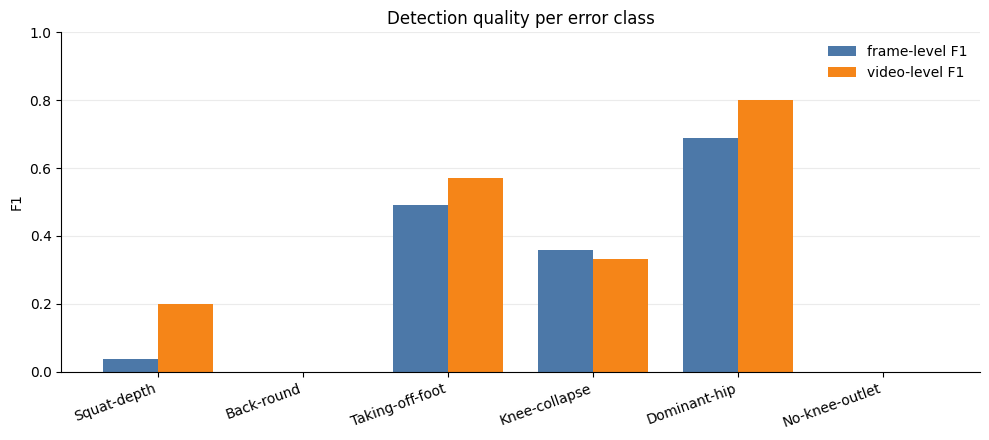

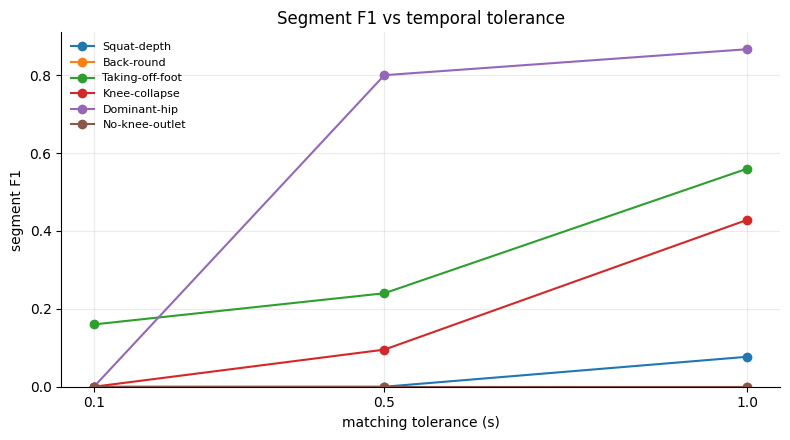

In [ ]:
# Pelny raport: zakres runu -> tabela per klasa -> segment-level -> wykresy
# -> karta kazdego bledu -> macierz nagranie x klasa -> odrzucone -> agregaty.
# Wykresy laduja tez jako PNG w metrics/figures/ wybranego runu.
#
# PER_VIDEO = True  -> rozbicie na poszczegolne nagrania
# PER_VIDEO = False -> czyste statystyki per klasa bledu, zsumowane po runie
PER_VIDEO = False

if report is not None:
    show_report(report, tolerance_s=1.0, save_figures=True, per_video=PER_VIDEO)


In [ ]:
# Pojedyncza klasa bledu do przyjrzenia sie z bliska.
# Zmien FOCUS_ERROR na dowolna z ERROR_CLASSES i uruchom komorke ponownie.
FOCUS_ERROR = 'Squat-depth'

if report is not None:
    show_class_card(report, FOCUS_ERROR, per_video=PER_VIDEO)


### Squat-depth

frame F1 **0.038** · precision 0.500 · recall 0.020 · support 1528 klatek

precision,recall,f1,tp,fp,fn,tn
0.500,0.125,0.200,1,1,7,33


,precision,recall,f1,tp,fp,fn,mean_temporal_iou,start_mae_s,end_mae_s
tolerance,,,,,,,,,
0.1s,0.000,0.000,0.000,0,2,24,—,—,—
0.5s,0.000,0.000,0.000,0,2,24,—,—,—
1s,0.500,0.042,0.077,1,1,23,0.526,0.167,0.733
